<a href="https://colab.research.google.com/github/k6jf8wfhxh-ux/Iris_classification/blob/main/lecture13_exercise_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第13回講義 演習

今回は，Variational autoencoder (VAE) [[1]](#scrollTo=XMIV_3TOiAq8) [[2]](#scrollTo=XMIV_3TOiAq8) を実装し，MNIST画像の再構成と生成，潜在空間の可視化などを行います．

---

# Lecture 13 Exercise

In this exercise, we implement a Variational Autoencoder (VAE) [[1]](#scrollTo=XMIV_3TOiAq8) [[2]](#scrollTo=XMIV_3TOiAq8), and work on MNIST image reconstruction and generation, as well as latent-space visualization.


## 目次

[【課題】Variational autoencoder（VAE）によるMNISTの画像生成](#scrollTo=IjKy6RoU5WeF)

1. [Variational autoencoder (VAE)の実装](#scrollTo=lDwFTAWbKXE-)
  
  1.1. [MNISTデータセットの読み込み](#scrollTo=kh_PpFMVKXFA)
  
  1.2. [VAEの復習](#scrollTo=5BNRLQm9KXFJ)
  
  1.3. [VAEの実装](#scrollTo=oWwOTcCzRNXb)
  
  1.4. [学習](#scrollTo=oYo_zWwBjrJ4)

2. [再構成画像の可視化](#scrollTo=PbS4E_GHKXFl)
  
  2.1. [Original image](#scrollTo=ZpVnPZjXKXFy)
  
  2.2. [Reconstruction image](#scrollTo=nVHNlRWAKXF6)

3. [潜在変数からランダムサンプリング](#scrollTo=WIUlxxxEKXF-)
4. [潜在空間のプロット](#scrollTo=sP6C1RqaSHDi)
5. [潜在空間の多様体の可視化](#scrollTo=yWyBK_14KXGW)

　 [参考文献](#scrollTo=XMIV_3TOiAq8)

---

## Table of Contents

[**Exercise**: MNIST Image Generation with a Variational Autoencoder (VAE)](#scrollTo=IjKy6RoU5WeF)

1. [Implementing a Variational Autoencoder (VAE)](#scrollTo=lDwFTAWbKXE-)

  1.1. [Loading the MNIST dataset](#scrollTo=kh_PpFMVKXFA)

  1.2. [Review of VAE](#scrollTo=5BNRLQm9KXFJ)

  1.3. [VAE implementation](#scrollTo=oWwOTcCzRNXb)

  1.4. [Training](#scrollTo=oYo_zWwBjrJ4)

2. [Visualizing reconstructed images](#scrollTo=PbS4E_GHKXFl)

  2.1. [Original image](#scrollTo=ZpVnPZjXKXFy)

  2.2. [Reconstruction image](#scrollTo=nVHNlRWAKXF6)

3. [Random sampling from latent variables](#scrollTo=WIUlxxxEKXF-)

4. [Plotting the latent space](#scrollTo=sP6C1RqaSHDi)

5. [Visualizing the latent-space manifold](#scrollTo=yWyBK_14KXGW)

[References](#scrollTo=XMIV_3TOiAq8)


In [ ]:
%matplotlib inline

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torch.nn.functional as F
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from typing import Tuple

rng = np.random.RandomState(1234)
random_state = 42

## 【課題】Variational autoencoder（VAE）によるMNISTの画像生成

---

## **Exercise**: MNIST Image Generation with a Variational Autoencoder (VAE)


## 1.Variational autoencoder（VAE）の実装

---

## 1. Implementing a Variational Autoencoder (VAE)


### 1.1. MNISTデータセットの読み込み

---

### 1.1. Loading the MNIST dataset


In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ]
)

batch_size = 128
device = 'cuda'
n_epochs = 15

dataloader_train = torch.utils.data.DataLoader(
    datasets.MNIST('./data/MNIST', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=False
)

dataloader_valid = torch.utils.data.DataLoader(
    datasets.MNIST('./data/MNIST', train=False, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.61MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.77MB/s]


### 1.2. VAEの復習

---

### 1.2. Review of VAE


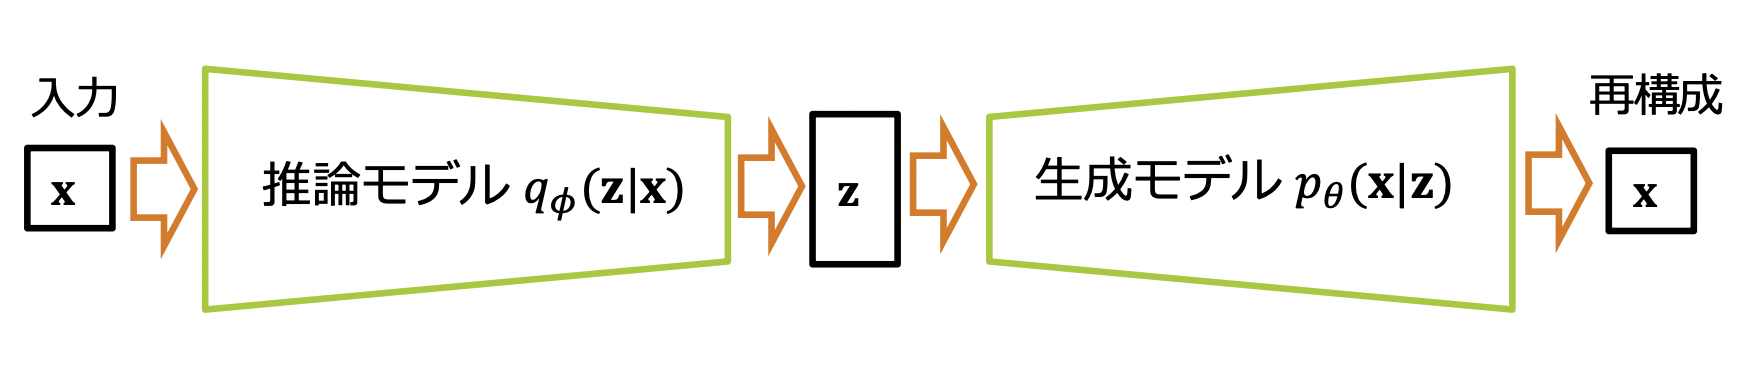

VAEのエンコーダとデコーダは，それぞれ次のように表されます．
- エンコーダ（例：ガウス分布）：
- デコーダ（例：ベルヌーイ分布）：
<br>

また，VAEの下界（目的関数）は次のとおりです．第1項が講義内の（負の）再構成誤差，第2項が正則化項に対応しています．

---

The VAE encoder and decoder can be written as follows.
- Encoder (e.g., Gaussian):
- Decoder (e.g., Bernoulli):
<br>

The VAE lower bound (objective) is given below. The first term corresponds to the (negative) reconstruction error discussed in the lecture, and the second term corresponds to the regularization term.

$$q_{\phi}({\bf z}\mid{\bf x}) = {\mathscr N}({\bf z}\mid \mu,\sigma^2{\bf I}), \quad \text{where } \mu=g^{\mu}_{\phi}({\bf x}), \ \sigma=g^{\sigma}_{\phi}({\bf x})$$

$$p_{\theta}({\bf x}\mid{\bf z}) = \mathrm{Ber}({\bf x}\mid \lambda), \quad \text{where } \lambda=f_{\theta}({\bf z})$$

$${\mathscr L}({\bf x};{\bf \theta},{\bf \phi}) = \mathbb{E}_{q_{\phi}({\bf z}\mid{\bf x})}[\log p_\theta({\bf x}\mid{\bf z})] -D_{KL}[q_{\phi}({\bf z}\mid{\bf x})||p({\bf z})]$$


目的関数の第1項は，次のようにサンプル近似できます．

なお，デコーダは[ベルヌーイ分布](https://ja.wikipedia.org/wiki/%E3%83%99%E3%83%AB%E3%83%8C%E3%83%BC%E3%82%A4%E5%88%86%E5%B8%83)なので，上式右辺は次のように計算できます．

上式は実装内の`reconstruction`に対応しています．今回の演習では$L=1$を採用します．また，Dはサンプルの次元数784に対応します．

目的関数の第2項については，次のように解析的に計算できます．（[正規分布同士のKLダイバージェンス](https://leenashekhar.github.io/2019-01-30-KL-Divergence/)）

上式は実装内の`KL`に対応しています．また，Jは潜在変数の次元数`z_dim`に対応します．

---

The first term in the objective can be approximated by sampling as follows.

Note that the decoder assumes a [Bernoulli distribution](https://ja.wikipedia.org/wiki/%E3%83%99%E3%83%AB%E3%83%8C%E3%83%BC%E3%82%A4%E5%88%86%E5%B8%83), so the right-hand side above can be computed as shown below.

The expression above corresponds to `reconstruction` in the implementation. In this exercise, we use $L=1$. Also, $D$ corresponds to the sample dimensionality 784.

For the second term in the objective, we can compute it analytically (the KL divergence between two Gaussian distributions) as shown below.

The expression above corresponds to `KL` in the implementation. Also, $J$ corresponds to the latent dimensionality `z_dim`.

$$
\mathbb{E}_{q_{\phi}(\mathbf{z}\mid \mathbf{x})}[\log p_\theta(\mathbf{x}\mid \mathbf{z})]
\simeq \frac{1}{L}\sum_{l=1}^L\log p_\theta(\mathbf{x}\mid \mathbf{z}^{(l)}),
\quad \text{where } \mathbf{z}^{(l)} = \mu + \sigma \odot \epsilon^{(l)},\ \epsilon^{(l)}\sim \mathcal{N}(0,\mathbf{I})
$$

$$
\frac{1}{L}\sum_{l=1}^L\log p_\theta(\mathbf{x}\mid \mathbf{z}^{(l)})
= \frac{1}{L}\sum_{l=1}^L \sum_{i=1}^D \left(x_i \log \lambda^{(l)}_i + (1-x_i)\log (1-\lambda^{(l)}_i)\right),
\quad \text{where } \lambda^{(l)} = f_{\theta}(\mathbf{z}^{(l)})
$$

$$
D_{KL}[q_{\phi}(\mathbf{z}\mid \mathbf{x})||p(\mathbf{z})]
= -\frac{1}{2}\sum_{j=1}^J\left(1+\log(\sigma_j^2)-\mu_j^2-\sigma_j^2\right),
\quad \text{where } p(\mathbf{z})=\mathcal{N}(0,\mathbf{I})
$$


### 1.3. VAEの実装

---

### 1.3. VAE implementation


以上を踏まえて，VAEを実装していきます．

- `__init__(self, z_dim)`

> エンコーダ，デコーダそれぞれを [`nn.Linear()`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=nn%20linear#torch.nn.Linear)からなる全結合型のニューラルネットワークとして構築します．
エンコーダではMNIST画像に対応して`self.dense_enc1`に784（=28*28）次元の入力を受け取り，次元削減により最終的には`z_dim`の出力特徴を持ちます．デコーダでは逆に次元を増加させます．

- `_encoder(self, x)`

>  入力画像`x`を受け取り，$\mu=g^{\mu}_{\phi}({\bf x}),\sigma=g^{\sigma}_{\phi}({\bf x}) $で定義した`mean, std`を返します．`std`がマイナスの値を取らないように [`F.softplus()`](https://pytorch.org/docs/stable/generated/torch.nn.functional.softplus.html#torch.nn.functional.softplus)を用います．

- `_sample_z(self, mean, var)`

> Backpropagationを可能にするため，再パラメータ化トリック (${\bf z}^{(l)} = \mu + \sigma \odot \epsilon^{(l)}$) を実装します．

- `_decoder(self, z)`

> 潜在変数`z`を受け取り，MNIST画像と同じ784次元になるまで次元を復元させ，`x`を返します．


- `forward(self, x)`

> 入力画像`x`を受け取り，再構成画像と潜在変数にあたる`x, z`を返します．

- `loss(self, x)`

> 目的関数を定義していきます．[上式](#scrollTo=kqrsxQunOryj&line=20&uniqifier=1)の通り実装し，目的関数の各項`KL`, `-reconstruction`を返します．注意点として，上式は最大化したい下界なので，ロスとしては符号が逆転し，これを最小化していくことになります．

---

Based on the above, we now implement the VAE.

- `__init__(self, z_dim)`

> Build the encoder and decoder as fully connected neural networks composed of [`nn.Linear()`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html?highlight=nn%20linear#torch.nn.Linear).
> In the encoder, `self.dense_enc1` takes a 784-dimensional input (28×28 for MNIST) and, through dimensionality reduction, the final output feature size becomes `z_dim`. The decoder does the reverse and increases the dimension.

- `_encoder(self, x)`

> Takes an input image `x` and returns `mean, std`, i.e., $\mu=g^{\mu}_{\phi}({\bf x}),\sigma=g^{\sigma}_{\phi}({\bf x})$.
> Use `F.softplus()` so that `std` does not take negative values.

- `_sample_z(self, mean, std)`

> Implement the reparameterization trick ($${\bf z}^{(l)} = \mu + \sigma \odot \epsilon^{(l)}$$) to enable backpropagation.

- `_decoder(self, z)`

> Takes latent variable `z`, restores the dimension back to 784 (same as MNIST), and returns the reconstructed image `x`.

- `forward(self, x)`

> Takes input image `x` and returns the reconstructed image and the latent variable, i.e., `x, z`.

- `loss(self, x)`

> Define the objective function. Implement it as in the [equation above](#scrollTo=kqrsxQunOryj&line=20&uniqifier=1), and return each term of the objective: `KL` and `-reconstruction`.
> Note: the equation is a lower bound that we want to **maximize**, but since we optimize by **minimizing** a loss, the sign is flipped in the implementation.


In [ ]:
def torch_log(x: torch.Tensor) -> torch.Tensor:
    """Prevent NaNs caused by torch.log(0).．
    """
    return torch.log(torch.clamp(x, min=1e-10))

# Implement the VAE model
class VAE(nn.Module):
    def __init__(self, z_dim: int) -> None:
        super().__init__()

        # Encoder: takes x as input and outputs Gaussian parameters (mu, sigma)
        self.dense_enc1 = nn.Linear(28*28, 200)
        self.dense_enc2 = nn.Linear(200, 200)
        self.dense_encmean = nn.Linear(200, z_dim)
        self.dense_encvar = nn.Linear(200, z_dim)

        # Decoder: takes z as input and outputs Bernoulli parameter (lambda)
        self.dense_dec1 = nn.Linear(z_dim, 200)
        self.dense_dec2 = nn.Linear(200, 200)
        self.dense_dec3 = nn.Linear(200, 28*28)

    def _encoder(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = F.relu(self.dense_enc1(x))
        x = F.relu(self.dense_enc2(x))
        mean = self.dense_encmean(x)
        std = F.softplus(self.dense_encvar(x))

        return mean, std

    def _sample_z(self, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
        if self.training:
            # Reparameterization trick: this random noise is not on the gradient path in the computational graph
            epsilon = torch.randn(mean.shape).to(device)
            return mean + std * epsilon
        else:
            return mean

    def _decoder(self, z: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.dense_dec1(z))
        x = F.relu(self.dense_dec2(x))
        # Apply sigmoid so that the output is in [0, 1]
        x = torch.sigmoid(self.dense_dec3(x))

        return x

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean, std = self._encoder(x)
        z = self._sample_z(mean, std)
        x = self._decoder(z)
        return x, z

    def loss(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean, std = self._encoder(x)

# Compute KL loss (regularization term). mean and std have shape (batch_size, z_dim)
# torch.sum corresponds to the sum over J (= z_dim). torch.mean averages over the batch_size.
# (batch averaging is not written explicitly in the equation)
        KL = -0.5 * torch.mean(torch.sum(1 + torch_log(std**2) - mean**2 - std**2, dim=1)) # WRITE ME

        z = self._sample_z(mean, std)
        y = self._decoder(z)

# Compute reconstruction loss (negative reconstruction error). x and y have shape (batch_size, 784)
# torch.sum corresponds to the sum over D (= 784). torch.mean averages over the batch_size.
        reconstruction = torch.mean(torch.sum(x * torch_log(y) + (1 - x) * torch_log(1 - y), dim=1)) # WRITE ME

        return KL, -reconstruction

### 1.4. 学習

---

### 1.4. Training


In [ ]:
z_dim = 2
assert z_dim >= 2

model = VAE(z_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(n_epochs):
    losses = []
    KL_losses = []
    reconstruction_losses = []

    model.train()
    for x, _ in dataloader_train:

        x = x.to(device)

        model.zero_grad()

# Compute each term: KL_loss and reconstruction_loss
        KL_loss, reconstruction_loss = model.loss(x)

# We maximize the ELBO, but implement it as a loss by minimizing the negative ELBO.
        loss = KL_loss + reconstruction_loss

        loss.backward()
        optimizer.step()

        losses.append(loss.cpu().detach().numpy())
        KL_losses.append(KL_loss.cpu().detach().numpy())
        reconstruction_losses.append(reconstruction_loss.cpu().detach().numpy())

    losses_val = []
    model.eval()
    for x, t in dataloader_valid:

        x = x.to(device)

        KL_loss, reconstruction_loss = model.loss(x)

        loss = KL_loss + reconstruction_loss

        losses_val.append(loss.cpu().detach().numpy())

    print('EPOCH: %d    Train Lower Bound: %lf (KL_loss: %lf. reconstruction_loss: %lf)    Valid Lower Bound: %lf' %
          (epoch+1, np.average(losses), np.average(KL_losses), np.average(reconstruction_losses), np.average(losses_val)))

EPOCH: 1    Train Lower Bound: 196.354996 (KL_loss: 3.310632. reconstruction_loss: 193.044357)    Valid Lower Bound: 174.762100
EPOCH: 2    Train Lower Bound: 168.222321 (KL_loss: 4.785280. reconstruction_loss: 163.437027)    Valid Lower Bound: 163.676727
EPOCH: 3    Train Lower Bound: 161.227631 (KL_loss: 5.252362. reconstruction_loss: 155.975266)    Valid Lower Bound: 158.988342
EPOCH: 4    Train Lower Bound: 157.625137 (KL_loss: 5.463500. reconstruction_loss: 152.161652)    Valid Lower Bound: 155.744522
EPOCH: 5    Train Lower Bound: 154.932755 (KL_loss: 5.600585. reconstruction_loss: 149.332169)    Valid Lower Bound: 153.132019
EPOCH: 6    Train Lower Bound: 153.073898 (KL_loss: 5.734068. reconstruction_loss: 147.339859)    Valid Lower Bound: 151.627060
EPOCH: 7    Train Lower Bound: 151.084915 (KL_loss: 5.872966. reconstruction_loss: 145.211960)    Valid Lower Bound: 149.954254
EPOCH: 8    Train Lower Bound: 150.016785 (KL_loss: 5.960288. reconstruction_loss: 144.056503)    Valid 

## 2.再構成画像の可視化

---

## 2. Visualizing reconstructed images


### 2.1. Original image

実サンプルを可視化しておきます．

---

### 2.1. Original image

First, visualize real samples.


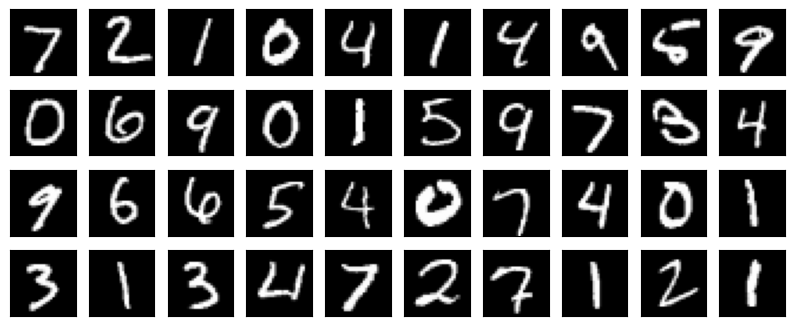

In [ ]:
valid_dataset = datasets.MNIST('./data/MNIST', train=False, download=True, transform=transform)
fig = plt.figure(figsize=(10, 4))
model.eval()
for i in range(40):
    x, t = valid_dataset[i]

    im = x.view(-1, 28, 28).permute(1, 2, 0).squeeze().numpy()

    ax = fig.add_subplot(4, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

### 2.2. Reconstruction image

モデルに実サンプルを入れて，再構成された画像を可視化します．

---

### 2.2. Reconstruction image

Feed real samples into the model and visualize the reconstructed images.


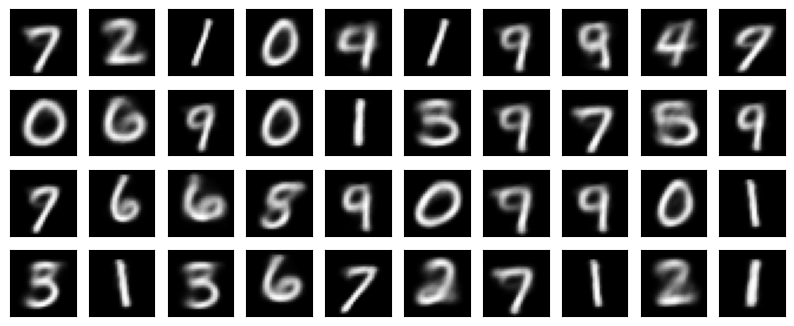

In [ ]:
valid_dataset = datasets.MNIST('./data/MNIST', train=False, download=True, transform=transform)
fig = plt.figure(figsize=(10, 4))
model.eval()
for i in range(40):
    x, t = valid_dataset[i]

    x = x.unsqueeze(0).to(device)

    y, z = model(x)

    im = y.view(-1, 28, 28).permute(1, 2, 0).detach().cpu().squeeze().numpy()

    ax = fig.add_subplot(4, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

## 3.ランダムサンプリング

潜在変数をランダムにサンプリングし，それをデコーダに通したものを可視化します．後で可視化する潜在空間の中でどの数字にも該当しない`z`もサンプリングされるので，数字に見えない画像も生成されます．

---

## 3. Random sampling

Randomly sample latent variables and visualize the decoder outputs. Since we may also sample `z` values that do not correspond to any digit in the latent space, some generated images may not look like digits.


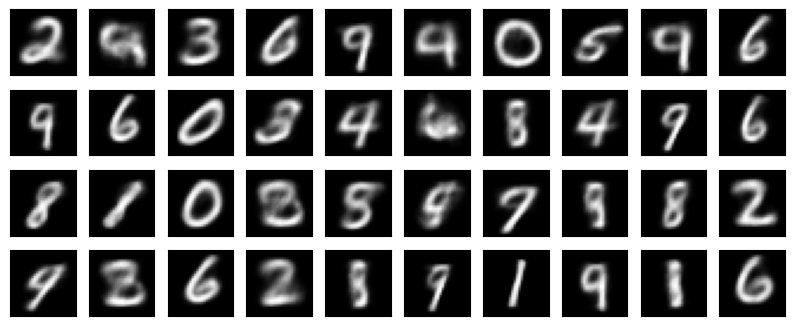

In [ ]:
z = torch.randn([40, z_dim]).to(device)

fig = plt.figure(figsize=(10, 4))
model.eval()
for i in range(40):
    y = model._decoder(z[i])

    im = y.view(-1, 28, 28).permute(1, 2, 0).detach().cpu().squeeze().numpy()

    ax = fig.add_subplot(4, 10, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

## 4.潜在空間のプロット

`z_dim=2`にして学習し，潜在変数を可視化してみましょう（`z_dim>2`の場合は，[t-SNE](https://distill.pub/2016/misread-tsne/)またはPCAで次元削減してプロットします）．

---

## 4. Plotting the latent space

Train with `z_dim=2` and visualize the latent variables (if `z_dim>2`, reduce the dimension to 2 with [t-SNE](https://distill.pub/2016/misread-tsne/) or PCA before plotting).


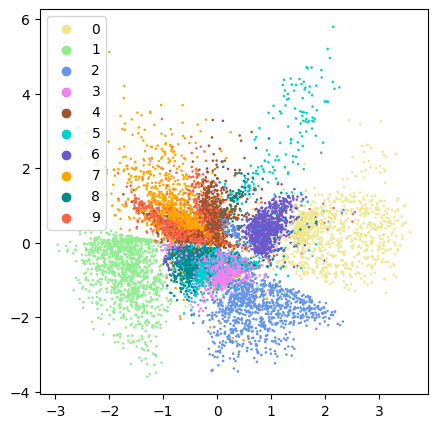

In [ ]:
valid_dataset = datasets.MNIST(
    './data/MNIST', train=False, download=True, transform=transform
)

model.eval()

z_list = []
t_list = []
for x, t in valid_dataset:
    t_list.append(t)
    x = x.to(device).unsqueeze(0)
    _, z = model(x)
    z_list.append(z.cpu().detach().numpy()[0])

z_val = np.stack(z_list)

REDUC = 'TSNE' # 'TSNE' or 'PCA'
if z_dim > 2:
    if REDUC == "TSNE":
        z_reduc = TSNE(n_components=2).fit_transform(z_val).T
    elif REDUC == "PCA":
        z_reduc = PCA(n_components=2).fit_transform(z_val).T
    else:
        raise ValueError("Please choose dimensionality reduction method from TSNE or PCA.")
elif z_dim == 2:
    z_reduc = z_val.T
else:
    raise ValueError("z dimensionality must be larger or equal to 2.")

colors = ['khaki', 'lightgreen', 'cornflowerblue', 'violet', 'sienna',
          'darkturquoise', 'slateblue', 'orange', 'darkcyan', 'tomato']

plt.figure(figsize=(5,5))
plt.scatter(*z_reduc, s=0.7, c=[colors[t] for t in t_list])
# Add legend
for i in range(10):
    plt.scatter([],[], c=colors[i], label=i)
plt.legend()

## 5.潜在空間の多様体の可視化

潜在空間内を，あるサンプルから別のサンプルまで遷移し，可視化してみましょう．

---

## 5. Visualizing the latent-space manifold

Let’s move within the latent space from one sample to another and visualize the transition.


start sample label: 7
end sample label: 0


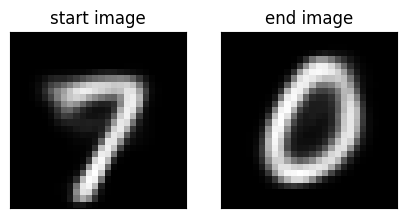

In [ ]:
START_SAMPLE_IDX = 0
END_SAMPLE_IDX = 3
TITLES = ["start", "end"]

valid_dataset = datasets.MNIST(
    './data/MNIST', train=False, download=True, transform=transform
)
model.eval()

z_dict = {}
fig = plt.figure(figsize=(5, 5))
for i, sample_idx in enumerate([START_SAMPLE_IDX, END_SAMPLE_IDX]):
    x, t = valid_dataset[sample_idx]
    print(f"{TITLES[i]} sample label: {t}")

    x = x.unsqueeze(0).to(device)
    y, z = model(x)

    image = y.view(-1, 28, 28).permute(1, 2, 0).detach().cpu().squeeze().numpy()
    z_dict.update({TITLES[i]: z})

    ax = fig.add_subplot(1, 2, i+1, xticks=[], yticks=[])
    ax.set_title(f"{TITLES[i]} image")
    ax.imshow(image, 'gray')

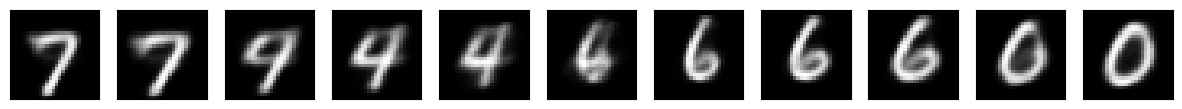

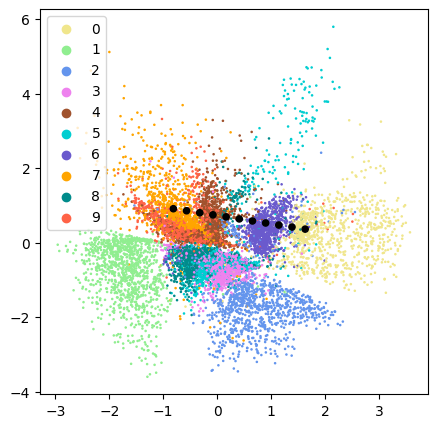

In [ ]:
# Linearly interpolate between z of the start sample and z of the end sample
z_interp = torch.cat(
    [torch.lerp(z_dict["start"], z_dict["end"], weight=w) for w in np.arange(0, 1.1, 0.1)]
)

images = model._decoder(z_interp).view(-1, 28, 28).detach().cpu().numpy()

fig = plt.figure(figsize=(15, 15))
for i, im in enumerate(images):
    ax = fig.add_subplot(1, 11, i+1, xticks=[], yticks=[])
    ax.imshow(im, 'gray')

z_interp = np.concatenate([z_val, z_interp.detach().cpu().numpy()], axis=0)

REDUC = "TSNE"
if z_dim > 2:
    if REDUC == "TSNE":
        z_reduc = TSNE(n_components=2).fit_transform(z_interp).T
    elif REDUC == "PCA":
        z_reduc = PCA(n_components=2).fit_transform(z_interp).T
    else:
        raise ValueError("Please choose dimensionality reduction method from TSNE or PCA.")
elif z_dim == 2:
    z_reduc = z_interp.T
else:
    raise ValueError("z dimensionality must be larger or equal to 2.")

t_list_interp = t_list + [10] * 11
colors_interp = colors + ["black"]
plt.figure(figsize=(5,5))
plt.scatter(
    *z_reduc,
    s=[0.7 if t < 10 else 20.0 for t in t_list_interp],
    c=[colors_interp[t] for t in t_list_interp]
)
# Add legend
for i in range(10):
    plt.scatter([],[], c=colors[i], label=i)
plt.legend()

In [ ]:
def torch_log(x: torch.Tensor) -> torch.Tensor:
    """Prevent NaNs caused by torch.log(0).．
    """
    return torch.log(torch.clamp(x, min=1e-10))

# Implement the VAE model
class VAE(nn.Module):
    def __init__(self, z_dim: int) -> None:
        super().__init__()

        # Encoder: takes x as input and outputs Gaussian parameters (mu, sigma)
        self.dense_enc1 = nn.Linear(28*28, 200)
        self.dense_enc2 = nn.Linear(200, 200)
        self.dense_encmean = nn.Linear(200, z_dim)
        self.dense_encvar = nn.Linear(200, z_dim)

        # Decoder: takes z as input and outputs Bernoulli parameter (lambda)
        self.dense_dec1 = nn.Linear(z_dim, 200)
        self.dense_dec2 = nn.Linear(200, 200)
        self.dense_dec3 = nn.Linear(200, 28*28)

    def _encoder(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        x = F.relu(self.dense_enc1(x))
        x = F.relu(self.dense_enc2(x))
        mean = self.dense_encmean(x)
        std = F.softplus(self.dense_encvar(x))

        return mean, std

    def _sample_z(self, mean: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
        if self.training:
            # Reparameterization trick: this random noise is not on the gradient path in the computational graph
            epsilon = torch.randn(mean.shape).to(device)
            return mean + std * epsilon
        else:
            return mean

    def _decoder(self, z: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.dense_dec1(z))
        x = F.relu(self.dense_dec2(x))
        # Apply sigmoid so that the output is in [0, 1]
        x = torch.sigmoid(self.dense_dec3(x))

        return x

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean, std = self._encoder(x)
        z = self._sample_z(mean, std)
        x = self._decoder(z)
        return x, z

    def loss(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean, std = self._encoder(x)

# Compute KL loss (regularization term). mean and std have shape (batch_size, z_dim)
# torch.sum corresponds to the sum over J (= z_dim). torch.mean averages over the batch_size.
# (batch averaging is not written explicitly in the equation)
        KL = -0.5 * torch.mean(torch.sum(1 + torch_log(std**2) - mean**2 - std**2, dim=1)) # WRITE ME

        z = self._sample_z(mean, std)
        y = self._decoder(z)

# Compute reconstruction loss (negative reconstruction error). x and y have shape (batch_size, 784)
# torch.sum corresponds to the sum over D (= 784). torch.mean averages over the batch_size.
        reconstruction = torch.mean(torch.sum(x * torch_log(y) + (1 - x) * torch_log(1 - y), dim=1)) # WRITE ME

        return KL, -reconstruction

## 参考文献

[[1]](https://arxiv.org/abs/1312.6114) Kingma & Welling, 2013,  "Auto-Encoding Variational Bayes", arXiv:1312.6114

[[2]](https://arxiv.org/abs/1401.4082) Rezende et al., 2014, "Stochastic Backpropagation and Approximate Inference in Deep Generative Models", arXiv:1401.4082

---

## References

[[1]](https://arxiv.org/abs/1312.6114) Kingma & Welling, 2013,  "Auto-Encoding Variational Bayes", arXiv:1312.6114

[[2]](https://arxiv.org/abs/1401.4082) Rezende et al., 2014, "Stochastic Backpropagation and Approximate Inference in Deep Generative Models", arXiv:1401.4082
